# Deep Learning

# Tutorial 10: MNIST Classification with Multi-Layer-Perceptron (MLP)

In this tutorial, we will cover:

- How to define and train a simple neural network for image classification

Prerequisites:

- Python, Tensor basics, Stochastic Gradient Descent

Our contacts:

- Niklas Beuter (niklas.beuter@th-luebeck.de)
- Fenja Falta (fenja.falta@th-luebeck.de)

Course:

- Slides and notebooks will be available at https://lernraum.th-luebeck.de/course/view.php?id=5383

### Imports

First, we import the necessary modules: `torch` for tensor operations, `torch.nn` for neural network modules, `torch.nn.functional` for activation and loss functions. `torchvision` provides the MNIST dataset, and `tqdm.notebook` creates practical progress bars during training.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from tqdm.notebook import tqdm

### Dataset Loading and Preprocessing

This cell loads the MNIST and CIFAR10 datasets, applies a transformation to convert images to tensors and normalize them. It then creates `DataLoader` objects for both the training and validation sets.

If you downloaded the dataset once, you can set `download=False` if you want to run the notebook again.

In [2]:
# Define preprocessing transformations for MNIST
mnist_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.1307,), (0.3081,))
])
# Define preprocessing transformations for CIFAR10
cifar10_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Standard CIFAR10 normalization
])

# Load MNIST datasets
mnist_dataset_train = torchvision.datasets.MNIST('./data', train=True, download=True, transform=mnist_transform)
mnist_dataset_val = torchvision.datasets.MNIST('./data', train=False, download=True, transform=mnist_transform)

# Load CIFAR10 datasets
cifar10_dataset_train = torchvision.datasets.CIFAR10('./data', train=True, download=True, transform=cifar10_transform)
cifar10_dataset_val = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=cifar10_transform)

print("Loaded both MNIST and CIFAR10 datasets.")

100%|██████████| 9.91M/9.91M [00:00<00:00, 57.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.64MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.21MB/s]
100%|██████████| 170M/170M [00:07<00:00, 24.0MB/s]


Loaded both MNIST and CIFAR10 datasets.


## Dataset Visualization

Let's visualize some images from the training sets. Our aim is to train a neural network that predicts the label based on an image as the input.

Visualizing MNIST examples:
MNIST image shape: torch.Size([1, 28, 28])
MNIST image shape: torch.Size([1, 28, 28])
MNIST image shape: torch.Size([1, 28, 28])
MNIST image shape: torch.Size([1, 28, 28])
MNIST image shape: torch.Size([1, 28, 28])


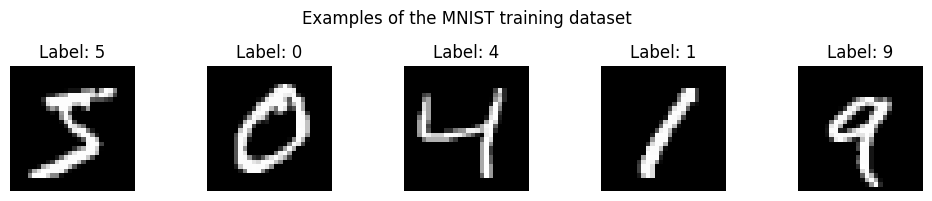

Visualizing CIFAR10 examples:
CIFAR10 image shape: torch.Size([3, 32, 32])
CIFAR10 image shape: torch.Size([3, 32, 32])
CIFAR10 image shape: torch.Size([3, 32, 32])
CIFAR10 image shape: torch.Size([3, 32, 32])
CIFAR10 image shape: torch.Size([3, 32, 32])


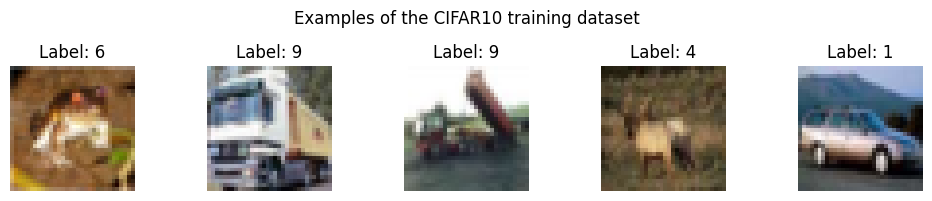

In [3]:
import matplotlib.pyplot as plt

# Visualize MNIST examples
print("Visualizing MNIST examples:")
fig_mnist = plt.figure(figsize=(10, 2))
for i in range(5):
    ax = fig_mnist.add_subplot(1, 5, i + 1)
    img_to_show = mnist_dataset_train[i][0]
    print(f"MNIST image shape: {img_to_show.shape}") # Image shape
    ax.imshow(img_to_show[0, :, :], cmap='gray')
    ax.set_title(f"Label: {mnist_dataset_train[i][1]}")
    ax.axis('off')
fig_mnist.suptitle('Examples of the MNIST training dataset')
plt.tight_layout()
plt.show()

# Visualize CIFAR10 examples
print("Visualizing CIFAR10 examples:")
# Define mean and std for denormalization (matching cifar10_transform)
cifar10_mean = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
cifar10_std = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)

fig_cifar = plt.figure(figsize=(10, 2))
for i in range(5):
    ax = fig_cifar.add_subplot(1, 5, i + 1)
    img_to_show = cifar10_dataset_train[i][0]
    print(f"CIFAR10 image shape: {img_to_show.shape}") # Image shape
    # Denormalize the image: img * std + mean
    img_to_show = img_to_show * cifar10_std + cifar10_mean
    # Clip values to [0, 1] after denormalization, just in case (e.g., due to floating point inaccuracies)
    img_to_show = torch.clamp(img_to_show, 0, 1)
    # Convert from CxHxW to HxWxC for matplotlib
    ax.imshow(img_to_show.permute(1, 2, 0))
    ax.set_title(f"Label: {cifar10_dataset_train[i][1]}")
    ax.axis('off')
fig_cifar.suptitle('Examples of the CIFAR10 training dataset')
plt.tight_layout()
plt.show()


Let's display a few examples of the same class from the training datasets.

MNIST '5' image shape: torch.Size([1, 28, 28])
MNIST '5' image shape: torch.Size([1, 28, 28])
MNIST '5' image shape: torch.Size([1, 28, 28])
MNIST '5' image shape: torch.Size([1, 28, 28])
MNIST '5' image shape: torch.Size([1, 28, 28])


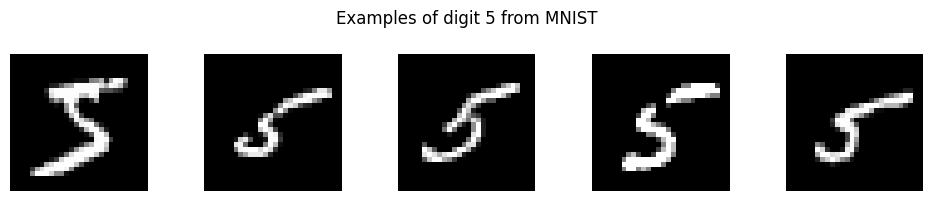

CIFAR10 'deer' image shape: torch.Size([3, 32, 32])
CIFAR10 'deer' image shape: torch.Size([3, 32, 32])
CIFAR10 'deer' image shape: torch.Size([3, 32, 32])
CIFAR10 'deer' image shape: torch.Size([3, 32, 32])
CIFAR10 'deer' image shape: torch.Size([3, 32, 32])


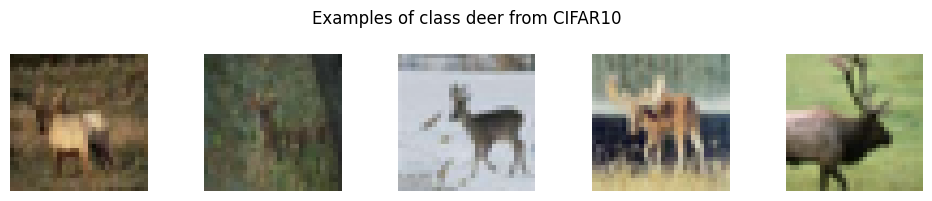

In [4]:
import matplotlib.pyplot as plt

# Visualize examples of digit '5' from MNIST
fig, axs = plt.subplots(1,5, figsize=(10, 2),gridspec_kw={'hspace': 0, 'wspace': 0}) # Adjusted figsize
idx_5 = [i for i, x in enumerate(mnist_dataset_train.targets) if x == 5]
for i, ax in enumerate(axs.flat):
      idx = idx_5[i]
      img_tensor = mnist_dataset_train[idx][0]
      print(f"MNIST '5' image shape: {img_tensor.shape}") # Added this line
      ax.imshow(img_tensor[0,:,:], cmap='gray')
      ax.axis('off')
plt.suptitle('Examples of digit 5 from MNIST')
plt.tight_layout()
plt.show()

# Visualize examples from a specific class (e.g., 'deer' which is label 4) from CIFAR10
class_label = 4 # Example: deer in CIFAR10
class_name = cifar10_dataset_train.classes[class_label]

# Define mean and std for denormalization (matching cifar10_transform)
cifar10_mean = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
cifar10_std = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)

fig, axs = plt.subplots(1,5, figsize=(10,2),gridspec_kw={'hspace': 0, 'wspace': 0}) # Adjusted figsize
idx_class = [i for i, x in enumerate(cifar10_dataset_train.targets) if x == class_label]
for i, ax in enumerate(axs.flat):
      idx = idx_class[i]
      img_to_show = cifar10_dataset_train[idx][0]
      print(f"CIFAR10 '{class_name}' image shape: {img_to_show.shape}") # Added this line
      # Denormalize the image: img * std + mean
      img_to_show = img_to_show * cifar10_std + cifar10_mean
      # Clip values to [0, 1] after denormalization
      img_to_show = torch.clamp(img_to_show, 0, 1)
      ax.imshow(img_to_show.permute(1, 2, 0))
      ax.axis('off')
plt.suptitle(f'Examples of class {class_name} from CIFAR10')
plt.tight_layout()
plt.show()

Since the dataset and networks we will be using are different, we want to define a helper function that gives us all necessary variables for our model (How many classes? What is the size of the image? How many channels does the input have? etc.).
> ## Exercise
> Complete the following helper function to return the variables.

In [5]:
# Helper function to get dataset parameters based on choice
def get_dataset_params(dataset_name):
    if dataset_name == "MNIST":
        return {
            "num_classes": 10, # TODO
            "input_size": 28 * 28,  # TODO (For MLP)
            "input_channels": 1,    # TODO (For CNN)
            "dataset_train": mnist_dataset_train,
            "dataset_val": mnist_dataset_val,
            "train_loader": torch.utils.data.DataLoader(mnist_dataset_train, batch_size=64),
            "val_loader": torch.utils.data.DataLoader(mnist_dataset_val, batch_size=1000)
        }
    elif dataset_name == "CIFAR10":
        return {
            "num_classes": 10,
            "input_size": 32 * 32, # TODO (For MLP)
            "input_channels": 3,    # TODO (For CNN)
            "dataset_train": cifar10_dataset_train,
            "dataset_val": cifar10_dataset_val,
            "train_loader": torch.utils.data.DataLoader(cifar10_dataset_train, batch_size=64, shuffle=True),
            "val_loader": torch.utils.data.DataLoader(cifar10_dataset_val, batch_size=1000, shuffle=False)
        }
    else:
        raise ValueError("Invalid dataset_name. Please select 'MNIST' or 'CIFAR10'.")


## CNN Model Definition (`MLPNet`)
We want to use the Multi-Layer Perceptron (MLP) from the last tutorial, and also define a new class named `CNNNet`, which is a convolutional neural network. Like before, we define all layers in the `__init__` function and our forward pass in the `forward` function, that gets the input to the network (the image tensor) and outputs the prediction (a value for each class). Unlike the last tutorial, we now want variable input (`input_size` for MLP, `input_channels` for CNN) and output (`num_classes`) configurations.
> ## Exercise
> 1. Define the layers of the MLPNet, but with variable input and output sizes.
> 2. Define the layers of `CNNNet`
>  - The network should consist of two convolutional layers (`nn.Conv2D(input_channels, output_channels, kernel_size, padding`). We want to use 3x3 kernels (`kernel_size=3`) and want to use padding that keeps the size of the image (`padding=?`). The first convolutional layer should map from the channel dimension to `32` features. The second convolutional layer should map from `32` to `64` features.
>  - Also define the pooling operation as `nn.MaxPool2D(2,2)`. The pooling operation takes the maximum value over a $2 \times 2$-sized patch.
> - Lastly, define a linear layer (also called fully connected layer) that acts as the classifier and maps from the total number of features to the number of classes. *How many features are there for MNIST and CIFAR respectively?*
> 3. After defining the layers, define the `forward` function. It should call the convolutional layers, each followed by a ReLU activation (`F.relu`) and the pooling operation. Afterwards, you need to flatten your image (`torch.flatten`, and be careful not to flatten the batch dimension) and can pass it to the classifier layer.

In [ ]:
class MLPNet(nn.Module):
    def __init__(self, num_classes=10, input_size=784):
        super(MLPNet, self).__init__()
        self.fc1 = nn.Linear(input_size, 128) # TODO
        self.fc2 = nn.Linear(128, num_classes) # TODO

    def forward(self, x):
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        return x

class CNNNet(nn.Module):
    def __init__(self, num_classes=10, input_channels=1):
        super(CNNNet, self).__init__()
        self.conv1 = nn.Conv2D(input_channels, output_channels=32, kernel_size=3, padding=1) # TODO
        self.conv2 = nn.Conv2D(32, output_channels=64, kernel_size=3, padding=1) #TODO
        self.pool = nn.MaxPool2D(2, 2) # TODO
        # Calculate linear layer input size based on input_channels (MNIST 28x28 or CIFAR 32x32)
        if input_channels == 1: # MNIST
            # 28x28 -> pool (14x14) -> pool (7x7)
            self.fc = nn.Linear(28 * 28, 128)# TODO
        elif input_channels == 3: # CIFAR10
            # 32x32 -> pool (16x16) -> pool (8x8)
            self.fc = nn.Linear(32 * 32, 128)# TODO
        else:
            raise ValueError("Unsupported input channels for CNNNet")

    def forward(self, x):
        # TODO

        return x

## Model Selection and Training Loop

The training and validation works identically to tutorial 09.

Reminder:

The network training happens in epochs, where 1 epoch means iterating over all batches of the training dataset. The general structure looks as follows:
```
for epoch in range(1, 15):
    epoch_train_loss = train(model, train_loader, optimizer, epoch)
    epoch_val_loss = validate(model, val_loader)
```
Now we need to define `train` and `validate` to train our model for one epoch and validate it on the validation data respectively.

To train the network, we first need to set the model into training mode by calling `model.train()`. Then we iterate over all batches to update our parameters.
The training itself is comprised of the following steps:
- Push the data onto the GPU with `.cuda()`
- Set the gradient that is saved in the optimizer to zero with `optimizer.zero_grad()`. This is necessary to only optimize on the current loss, because otherwise we would add our current gradient to the last one.
- Call the forward pass of the model with `model(data)`. The output is your current prediction. When `model.train()` is active, the gradient is stored at the same time.
-  Compute the loss. Since we have a classification problem, we want to use a Cross-Entropy-Loss (`F.cross_entropy`)
- Perform the backward pass by calling `.backward()` on the loss. This computes the gradients and saves them internally.
- Update the parameters by calling `.step()` on the optimizer.

> ## Exercise
> Complete the `train` function based on the description above.

In [ ]:
def train(model, train_loader, optimizer, epoch):
     # TODO: Set model to training mode
    total_loss = 0
    for batch_idx, (data, target) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch} Training")):
        data, target =  # TODO: Move data and target to GPU
         # TODO: Zero the gradients before running the backward pass
        output =  # TODO: Perform a forward pass
        loss = # TODO: Calculate Cross-Entropy Loss
         # TODO: Perform a backward pass to compute gradients
         # TODO: Update model parameters
        total_loss += loss.item() # Accumulate the loss

    avg_epoch_loss = total_loss / len(train_loader)
    print(f'Train Epoch: {epoch} - Average Loss: {avg_epoch_loss:.6f}')
    return avg_epoch_loss

For validation, we can set the model to evaluation mode by calling `model.eval()`. Since we do not perform backpropagation on our validation data, we do not need to save the gradients, so we can work in a `torch.no_grad()` environment. We then only need to perform the forward pass and calculate the loss on the validation dataset. Since validation does not need to be differentiable, we can also gain the exact prediction, which is the return of the `argmax` function instead of the differentiable `softmax`, which is contained in our Cross-Entropy loss.
> ## Exercise
> Complete the `validate` function.

In [ ]:
def validate(model, val_loader):
    model.eval() #TODO: Set model to evaluation mode.
    val_loss = 0
    correct = 0
    with torch.no_grad(): # Disable gradient calculation for validation
        for data, target in tqdm(val_loader, desc=f"Epoch {epoch} Validation"):
            data, target = # TODO: Move data and target to GPU
            output = # TODO: Perform a forward pass
            curr_val_loss =  # TODO: Calculate Cross-Entropy Loss
            pred = output.argmax(dim=1, keepdim=True) # Get the index of the max log-probability as prediction
            correct += pred.eq(target.view_as(pred)).sum().item() # Count correct predictions
            val_loss += curr_val_loss.item()

    val_loss /= len(val_loader) # Calculate average validation loss

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        val_loss, correct, len(val_loader.dataset),
        100. * correct / len(val_loader.dataset))) # Print validation metrics
    return val_loss

Now we can run our training and validation functions. We need to optimize all parameters of our model that are initialized in the `__init__`. These can be accessed via `model.parameters()`
> ## Exercise
> Initialize the model (remember to pass the variables `num_classes` and `input_size`/`input_channels`, and push it to cuda) and choose Adam as your optimizer. How does the accuracy differ between the configurations? How and why do the number of parameters differ?

In [ ]:
# Define all configurations to run (uncomment to train multiple)
configurations = [
    #{"dataset": "MNIST", "model": "MLP"},
    {"dataset": "MNIST", "model": "CNN"},
    #{"dataset": "CIFAR10", "model": "MLP"},
    #{"dataset": "CIFAR10", "model": "CNN"}
]

all_results = []

for config in configurations:
    dataset_choice = config["dataset"]
    model_choice = config["model"]

    print(f"\n--- Running Configuration: Dataset={dataset_choice}, Model={model_choice} ---")

    # Get dataset specific parameters
    params = get_dataset_params(dataset_choice)
    num_classes = params["num_classes"]
    input_size = params["input_size"]
    input_channels = params["input_channels"]
    train_loader = params["train_loader"]
    val_loader = params["val_loader"]

    # Initialize the model based on choice
    if model_choice == "MLP":
        model =  # TODO
    elif model_choice == "CNN":
        model =  # TODO
    else:
        raise ValueError("Invalid model choice")

    # Print number of parameters
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model: {model_choice}, Number of trainable parameters: {total_params}")

    optimizer = # TODO: Use Adam optimizer

    current_train_losses = []
    current_val_losses = []

    for epoch in range(11): # Run for 11 epochs
        epoch_train_loss = train(model, train_loader, optimizer, epoch)
        epoch_val_loss = validate(model, val_loader)
        current_train_losses.append(epoch_train_loss)
        current_val_losses.append(epoch_val_loss)

    all_results.append({
        "name": f"{model_choice} - {dataset_choice}",
        "train_losses": current_train_losses,
        "val_losses": current_val_losses
    })

> ## Exercise
> After training, we can visualize the loss curves. How do the loss curves differ?

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.figure(figsize=(12, 6))

# Get a colormap for distinct colors for each configuration
colors = cm.get_cmap('rainbow', len(all_results))

for i, result in enumerate(all_results):
    color = colors(i)
    plt.plot(result["train_losses"], label=f'{result["name"]} Training', color=color, linestyle='-')
    plt.plot(result["val_losses"], label=f'{result["name"]} Validation', color=color, linestyle='--')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses for All Configurations')
plt.legend()
plt.grid(True)
plt.show()